In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils import *

In [17]:
# Load dataset
ds = load_jsonl_file('./../datasets/MATE-dev/mm_0shot_llava_hfllava_1.5_7b_hf.jsonl')
nobjects=3

# Filter dataset for a specific number of objects 
ds_ = [data for data in ds if data['object_count'] == nobjects]

5500it [00:00, 6334.35it/s]


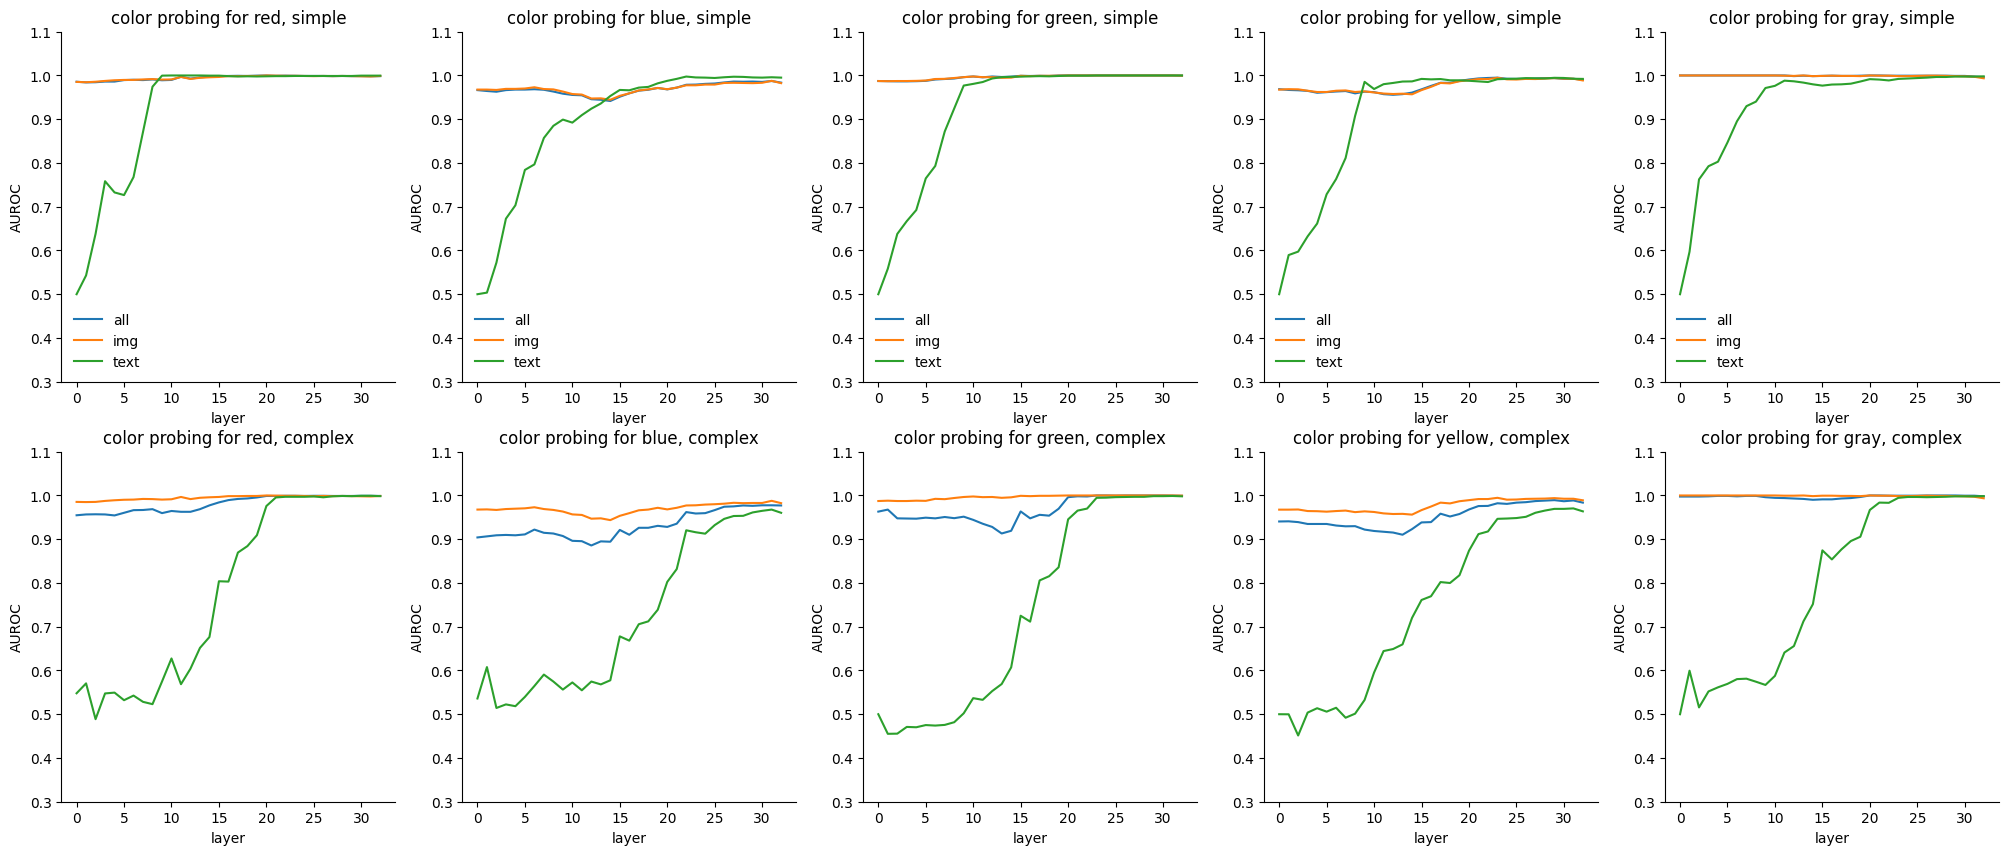

In [16]:
###### plot color probe results
task='color'
targets=['red', 'blue','green','yellow', 'gray']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
prompt_level = ['simple','complex']

fig,axs = plt.subplots(len(prompt_level), len(targets), figsize=(5*len(targets), 5*len(prompt_level)))

for idx, prompt_type in enumerate(prompt_level): 
    for jdx, target in enumerate(targets):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)
        plot_df['layer'] = list(range(33))*6
        plot_df['Mean pooling'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        plot_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in plot_df['Mean pooling']]
        plot_df['Tokens'] = [i.split('_')[1] for i in plot_df['embedding_level']]
        plot_df = plot_df[plot_df['Mean pooling']=='over embedding dimension']
        

        b = sns.lineplot(data=plot_df,
                            x='layer', y=metric, hue='Tokens',
                            ax=axs[idx][jdx])
        
        gold_reference = ['Yes' if target in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)
        baseline = 0.5

        # b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
        b.set_title(f"{task} probing for {target}, {prompt_type}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False)
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)

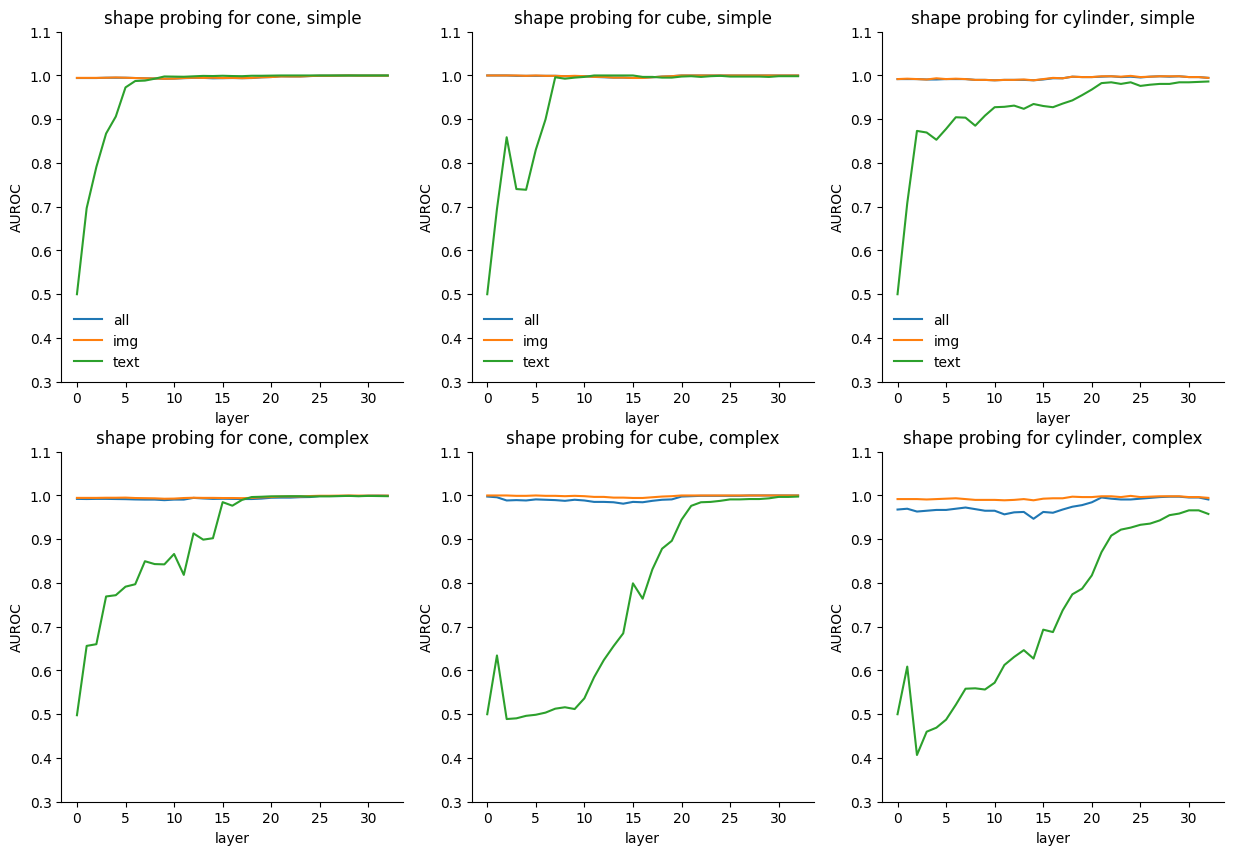

In [ ]:
###### plot color shape probe results
task='shape'
targets=['cone', 'cube', 'cylinder']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
mode = 'image'  # 'image', 'text'
prompt_level = ['simple','complex']

fig,axs = plt.subplots(len(prompt_level), len(targets), figsize=(5*len(targets), 5*len(prompt_level)))

for idx, prompt_type in enumerate(prompt_level): 
    for jdx, target in enumerate(targets):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/{prompt_type}/probing_results_{task}_{target}_{nobjects}.csv", index_col=0)
        plot_df['layer'] = list(range(33))*6
        plot_df['Mean pooling'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        plot_df['Mean pooling'] = ['over embedding dimension' if i=='sentence' else 'over token' for i in plot_df['Mean pooling']]
        plot_df['Tokens'] = [i.split('_')[1] for i in plot_df['embedding_level']]
        plot_df = plot_df[plot_df['Mean pooling']=='over embedding dimension']
        

        b = sns.lineplot(data=plot_df,
                            x='layer', y=metric, hue='Tokens',
                            ax=axs[idx][jdx])
        
        gold_reference = ['Yes' if target in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)
        baseline = 0.5

        # b.axhline(y=baseline, color='black', linestyle=':', linewidth=2)
        b.set_title(f"{task} probing for {target}, {prompt_type}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False)
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)


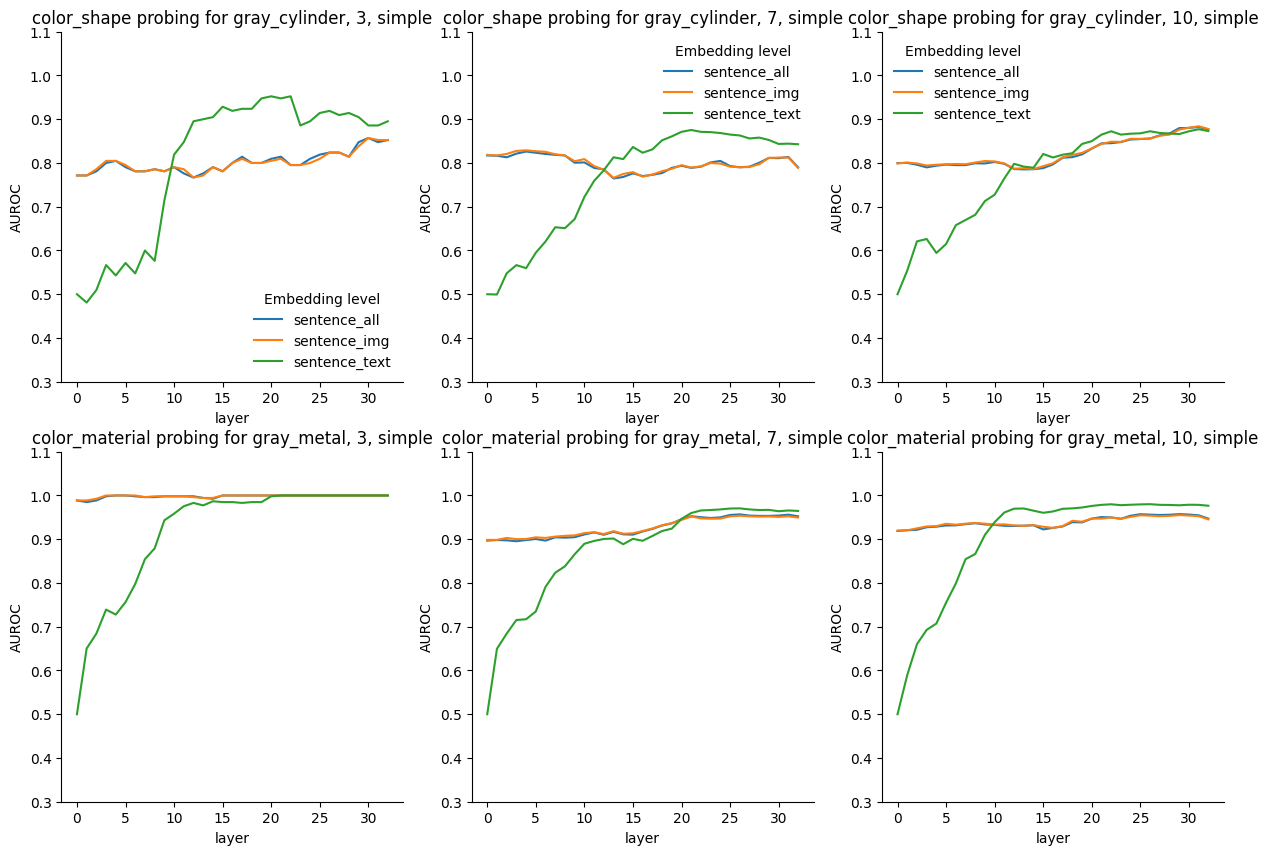

In [23]:
###### plot color_shape probe results
tasks=['color_shape', 'color_material']
targets=['gray_cylinder', 'gray_metal']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
prompt_type = 'simple'
nobjects = [3, 7, 10]
mode = 'image'  # 'image', 'text'


fig,axs = plt.subplots(len(targets), len(nobjects), figsize=(5*len(nobjects), 5*len(targets)))

for idx, (target, task) in enumerate(zip(targets,tasks)):   
    for jdx, nobject in enumerate(nobjects):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/{prompt_type}/probing_results_{task}_{target}_{nobject}.csv", index_col=0)
        plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        plot_df['layer'] = list(range(33))*6
        b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                        x='layer', y=metric, hue='embedding_level', 
                        ax=axs[idx][jdx])
        # gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        # gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        # baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

        # b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
        b.set_title(f"{task} probing for {target}, {nobject}, {prompt_type}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False,
                    title='Embedding level')
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)

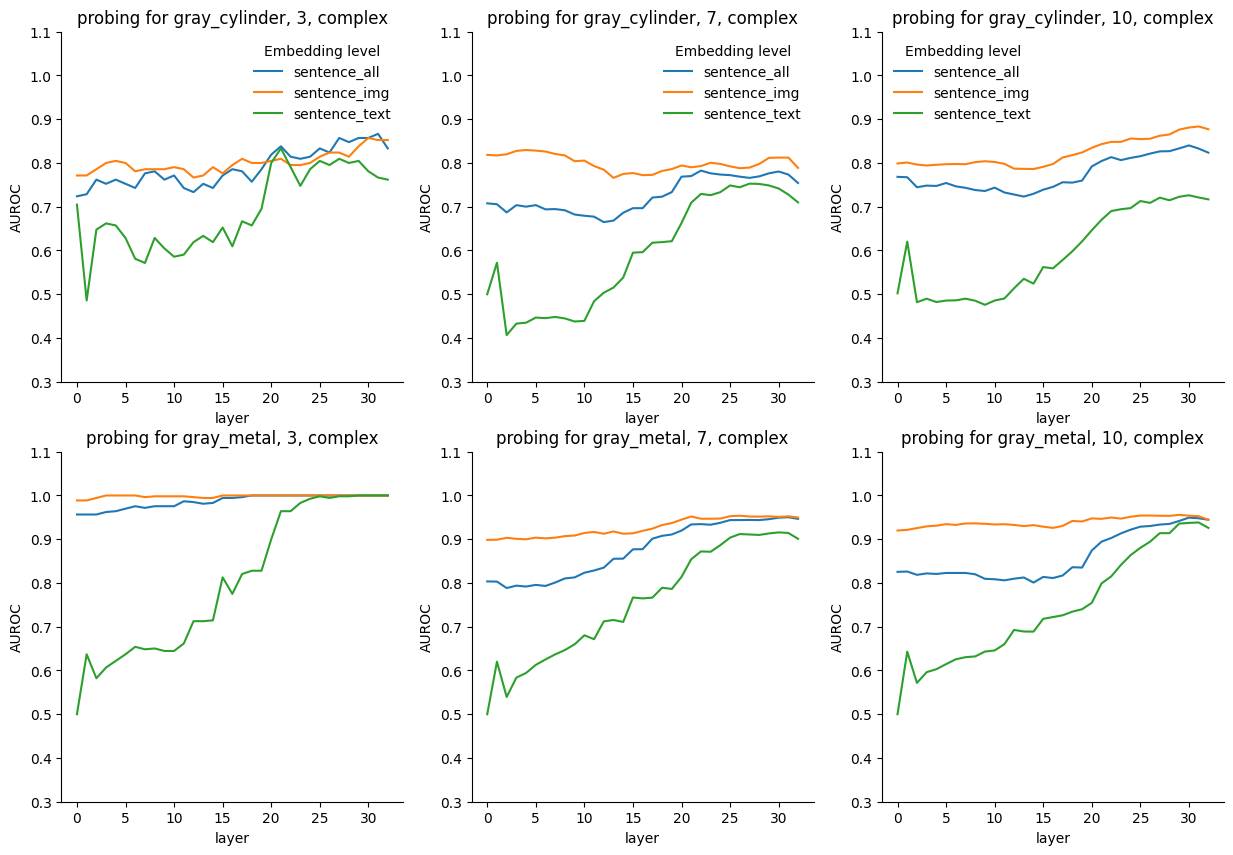

In [41]:
###### plot color_shape probe results
tasks=['color_shape', 'color_material']
targets=['gray_cylinder', 'gray_metal']
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
prompt_type = 'complex'
nobjects = [3, 7, 10]
mode = 'image'  # 'image', 'text'


fig,axs = plt.subplots(len(targets), len(nobjects), figsize=(5*len(nobjects), 5*len(targets)))

for idx, (target, task) in enumerate(zip(targets,tasks)):   
    for jdx, nobject in enumerate(nobjects):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/{prompt_type}/probing_results_{task}_{target}_{nobject}.csv", index_col=0)
        plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        plot_df['layer'] = list(range(33))*6
        b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                        x='layer', y=metric, hue='embedding_level', 
                        ax=axs[idx][jdx])
        # gold_reference = ['Yes' if t in set([o['color'] for o in data['scene']['objects']]) else 'No' for data in ds_]
        # gold_reference_binary = [1 if i=='Yes' else 0 for i in gold_reference]
        # baseline = np.sum(gold_reference_binary) / len(gold_reference_binary)

        # b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
        b.set_title(f"probing for {target}, {nobject}, {prompt_type}")
        b.set_ylabel(metric.upper())

        if idx == 0:
            b.legend(frameon=False,
                    title='Embedding level')
        else:
            b.legend_.remove()

        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)

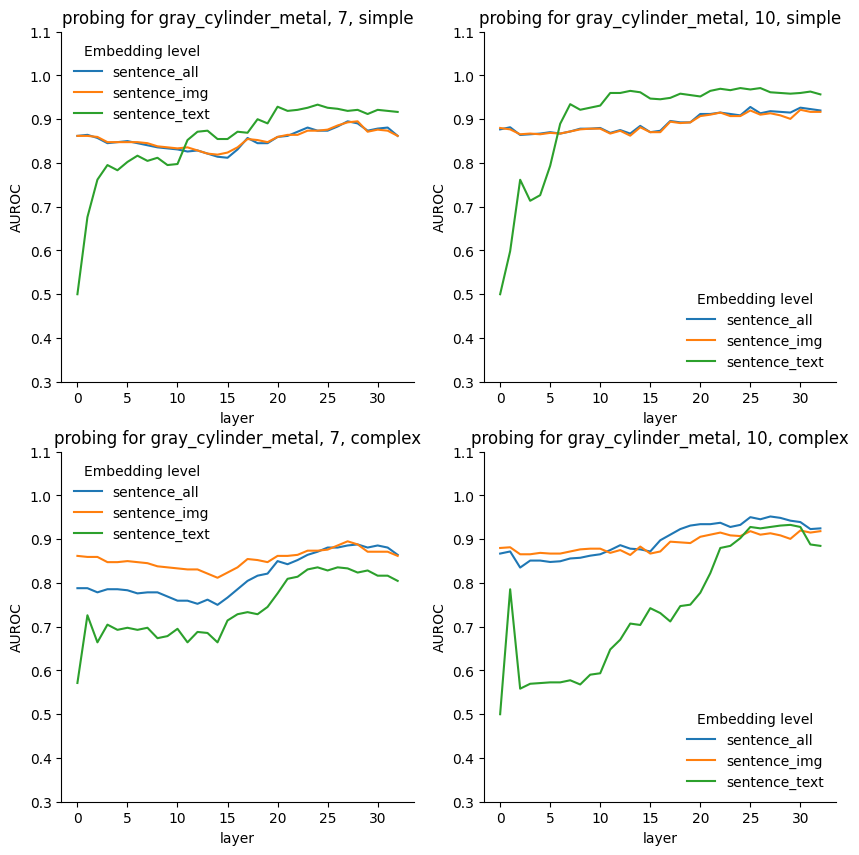

In [14]:
###### plot color_shape_material probe results
task='color_shape_material'
target='gray_cylinder_metal'
metric = 'auroc'  # 'auroc', 'accuracy', 'auprc'
prompt_level = ['simple', 'complex']
nobjects = [7, 10]
mode = 'image'  # 'image', 'text'


fig,axs = plt.subplots(len(prompt_level), len(nobjects), figsize=(5*len(nobjects), 5*len(prompt_level)))

for idx, prompt_type in enumerate(prompt_level):   
    for jdx, nobject in enumerate(nobjects):
        plot_df = pd.read_csv(f"./results/llava7B/linear_probing/probe_{mode}/{prompt_type}/probing_results_{task}_{target}_{nobject}.csv", index_col=0)
        plot_df['embeddings_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]
        plot_df['layer'] = list(range(33))*6
        b = sns.lineplot(data=plot_df[plot_df['embeddings_over']=='sentence'],
                        x='layer', y=metric, hue='embedding_level', 
                        ax=axs[idx][jdx])

        # b.axhline(y=baseline, color='black', linestyle='--', linewidth=1)
        b.set_title(f"probing for {target}, {nobject}, {prompt_type}")
        b.set_ylabel(metric.upper())

        b.legend(frameon=False,
                title='Embedding level')


        b.set(ylim=(0.3,1.1))


sns.despine(top=True, right=True)

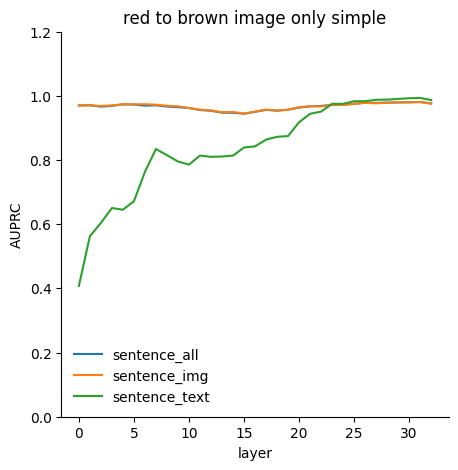

In [15]:
## Mutation, i.e. replacing target with another target
metric = 'auprc'

fig, axs = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(5, 5)
)


plot_df = pd.read_csv(f'./results/llava7B/linear_probing/probe_image/mutate/probing_results_color_red_to_brown_3.csv', index_col=0)
plot_df['embedding_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]

b = sns.lineplot(
    data=plot_df[plot_df['embedding_over']=='sentence'],
    x='layer',
    y=metric,
    hue='embedding_level',
    ax=axs
)
# b.axhline(auprc_baseline, color='black', linestyle='--')
b.set(ylim=(0,1.2))
b.legend(frameon=False)
b.set_ylabel(metric.upper())
b.set_title(f"red to brown image only simple")



sns.despine(top=True, right=True)

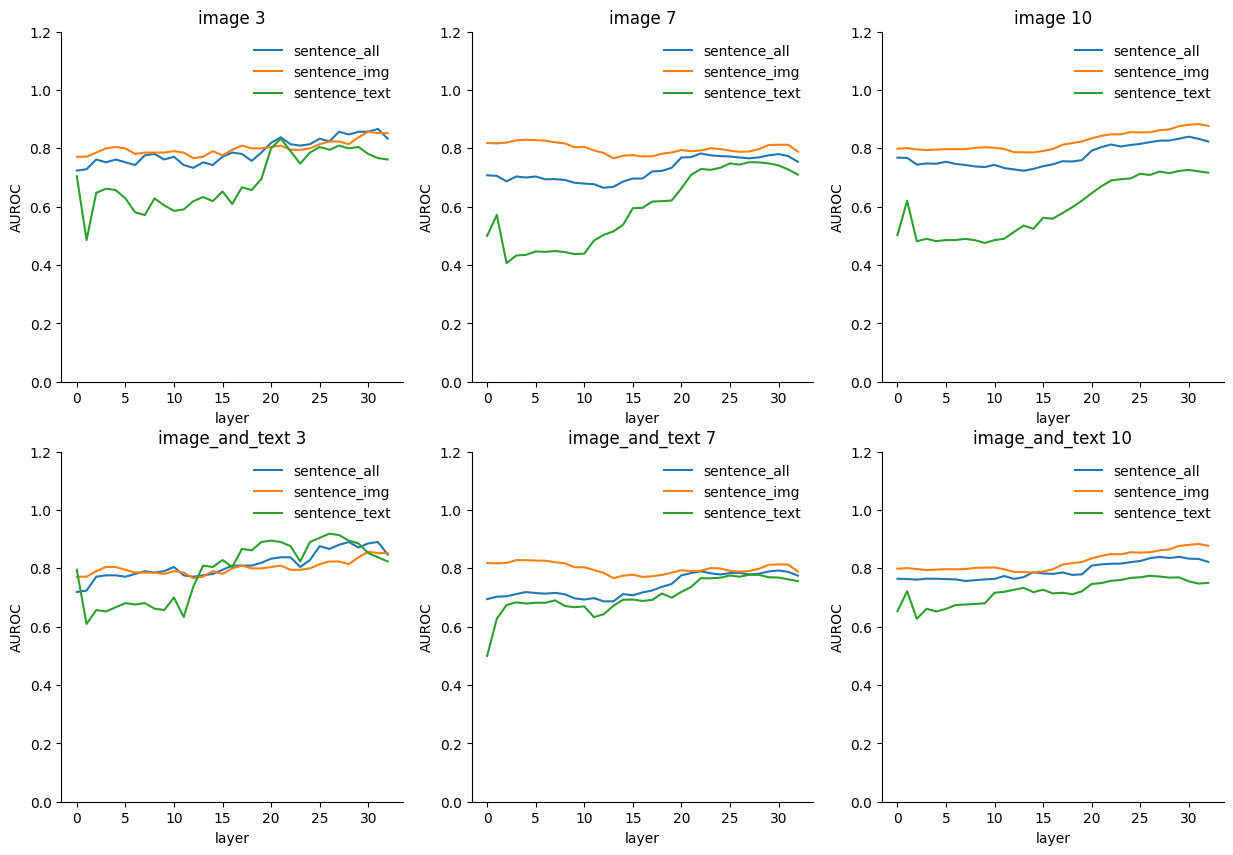

In [ ]:
## gray_cylinder 3,7,10
metric = 'auroc'

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)

for idx, task in enumerate(['image','image_and_text']):
    for jdx, nobj in enumerate([3,7,10]):

        plot_df = pd.read_csv(f'./results/llava7B/linear_probing/probe_{task}/complex/probing_results_color_shape_gray_cylinder_{nobj}.csv', index_col=0)
        plot_df['embedding_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]

        b = sns.lineplot(
            data=plot_df[plot_df['embedding_over']=='sentence'],
            x='layer',
            y=metric,
            hue='embedding_level',
            ax=axs[idx][jdx]
        )

        b.set(ylim=(0,1.2))
        b.legend(frameon=False)
        b.set_ylabel(metric.upper())
        b.set_title(f"{task} {nobj}")



sns.despine(top=True, right=True)

/tmp/ipykernel_15170/3767748279.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  b.legend(frameon=False)
/tmp/ipykernel_15170/3767748279.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  b.legend(frameon=False)


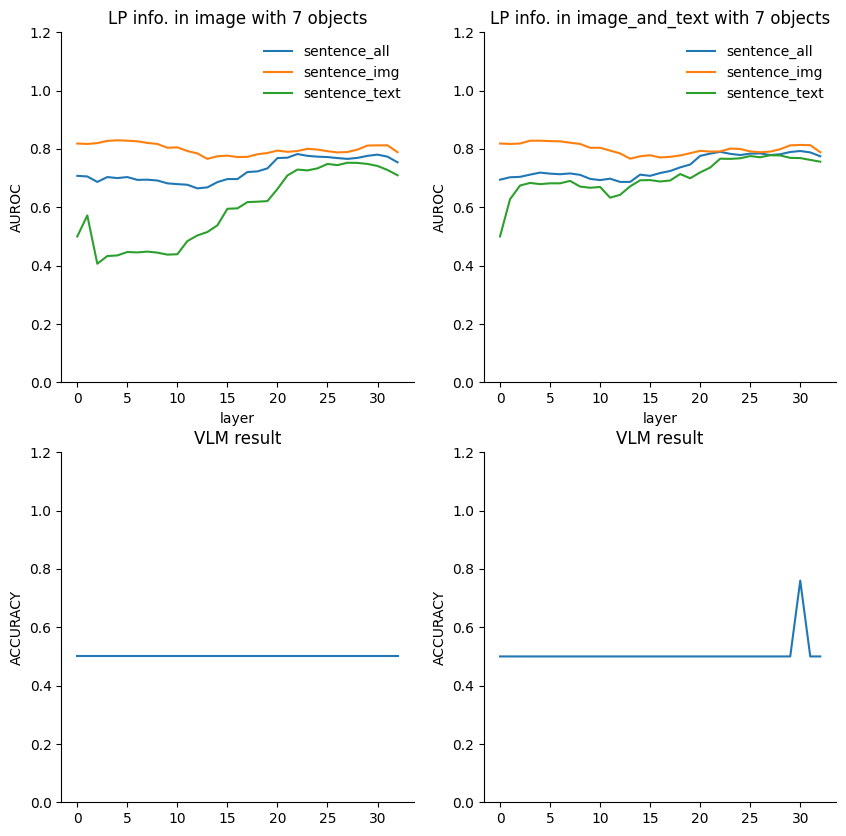

In [14]:
## gray_cylinder 7
metric = 'auroc'

fig, axs = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 10)
)

for jdx, task in enumerate(['image','image_and_text']):
    nobj=7
    plot_df = pd.read_csv(f'./results/llava7B/linear_probing/probe_{task}/complex/probing_results_color_shape_gray_cylinder_{nobj}.csv', index_col=0)
    plot_df['embedding_over'] = [i.split('_')[0] for i in plot_df['embedding_level']]

    b = sns.lineplot(
        data=plot_df[plot_df['embedding_over']=='sentence'],
        x='layer',
        y=metric,
        hue='embedding_level',
        ax=axs[0][jdx]
    )

    b.set(ylim=(0,1.2))
    b.legend(frameon=False)
    b.set_ylabel(metric.upper())
    b.set_title(f"LP info. in {task} with {nobj} objects")

metric='accuracy'
for jdx, task in enumerate(['image','image_and_text']):
    nobj=7
    plot_df = pd.read_csv(f'./results/llava7B/linear_probing/layer_predictions/layer_{task}_gray_cylinder_{nobj}.csv', index_col=0)

    b = sns.lineplot(
        data=plot_df.iloc[:33],
        x=list(range(33)),
        y=metric,
        ax=axs[1][jdx]
    )

    b.set(ylim=(0,1.2))
    b.legend(frameon=False)
    b.set_ylabel(metric.upper())
    b.set_title(f"VLM result")


sns.despine(top=True, right=True)

In [4]:
plot_df = pd.read_csv(f'./results/llava7B/linear_probing/layer_predictions/layer_image_and_text_gray_cylinder_{7}.csv', index_col=0)
plot_df

,accuracy,f1_macro,precision_macro,recall_macro,f1_micro,precision_micro,recall_micro,layer
0,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,0
1,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,1
2,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,2
3,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,3
4,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,4
5,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,5
6,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,6
7,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,7
8,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,8
9,0.50,0.333333,0.250000,0.50,0.50,0.50,0.50,9
